In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [3]:
data.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
data.duplicated().sum()

np.int64(449)

In [5]:
data.dropna(inplace=True)

In [6]:
data.duplicated().sum()

np.int64(350)

In [7]:
# import some libraries for nlp task
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


download the required NLTK datasets:


1.   **stopwords** → list of common stopwords
2.  **wordnet** → dictionary database used by the lemmatizer





This is a very common setup for text preprocessing in NLP, where you:

Clean text with re
Remove stopwords
Lemmatize words to their root form before analysis or machine learning.

In [8]:
# download necessary dataset
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

The `clean_comment` column appears to be empty in the current state of the DataFrame. Let's reload the data to ensure we start with the original content before applying the preprocessing function again.

In [9]:
# Reload the data to ensure the 'clean_comment' column has its original content
data = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

# Drop NaN values and duplicates again, as this was done previously after initial load
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

Now, let's define the `preprocess` function with all the necessary steps for cleaning text. This function will convert text to lowercase, remove extra spaces and newlines, filter out special characters, remove common stopwords (excluding negation words), and lemmatize words to their base form.

In [10]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize stopwords and lemmatizer once
stop_words = set(stopwords.words('english')) - {'not', 'however', 'no', 'yet'}
lemmatizer = WordNetLemmatizer()

def preprocess(comment):
    # Ensure comment is a string; return empty string for non-string types
    if not isinstance(comment, str):
        return ""

    # Convert to lower case
    comment = comment.lower()

    # Remove leading/trailing spaces
    comment = comment.strip()

    # Remove newlines and replace with a single space
    comment = re.sub(r'[\r\n]+', ' ', comment)

    # Remove special characters, keeping only letters, numbers, spaces, and essential punctuation
    comment = re.sub(r'[^a-z0-9\s!?.,]', '', comment) # Lowercase alpha-numeric, space, and specific punctuation

    # Remove stopwords
    comment = ' '.join(
        word for word in comment.split()
        if word not in stop_words
    )

    # Lemmatize words
    comment = ' '.join(
        lemmatizer.lemmatize(word)
        for word in comment.split()
    )

    return comment

Now that the data is reloaded and the `preprocess` function is defined, we can apply it to the `clean_comment` column. We will then display the head of the DataFrame to verify the preprocessing was successful.

In [11]:
# Apply the preprocess function to the 'clean_comment' column
data['clean_comment'] = data['clean_comment'].apply(preprocess)

# Display the first few rows of the DataFrame with the preprocessed comments
display(data.head())

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [21]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split,cross_val_predict,StratifiedKFold
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# vectorize the comments using Bag of words (CountVectorizer)
vectorizer = CountVectorizer(max_features=5000)

In [15]:
X = vectorizer.fit_transform(data['clean_comment']).toarray()
y = data['category']

In [16]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [17]:
X.shape

(36799, 5000)

In [18]:
data.shape

(36799, 2)

### Split the data into training and testing sets

We'll split the dataset into 80% for training and 20% for testing. This allows us to train the model on a portion of the data and evaluate its performance on unseen data.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (29439, 5000)
Testing features shape: (7360, 5000)
Training target shape: (29439,)
Testing target shape: (7360,)


### Train a RandomForestClassifier model

We'll use a `RandomForestClassifier` to build our sentiment analysis model. Random Forests are powerful ensemble methods that can handle high-dimensional data well.

In [22]:
model = RandomForestClassifier(n_estimators=150,max_depth=15, random_state=42, n_jobs=-1) # Use n_jobs=-1 to utilize all available cores
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


### Evaluate the model's performance

Now, let's make predictions on the test set and evaluate the model using accuracy, a classification report, and a confusion matrix. This will give us insights into how well our model is performing.

Accuracy: 0.6461

Classification Report:

              precision    recall  f1-score   support

          -1       1.00      0.02      0.04      1650
           0       0.65      0.84      0.73      2556
           1       0.64      0.82      0.72      3154

    accuracy                           0.65      7360
   macro avg       0.76      0.56      0.50      7360
weighted avg       0.72      0.65      0.57      7360



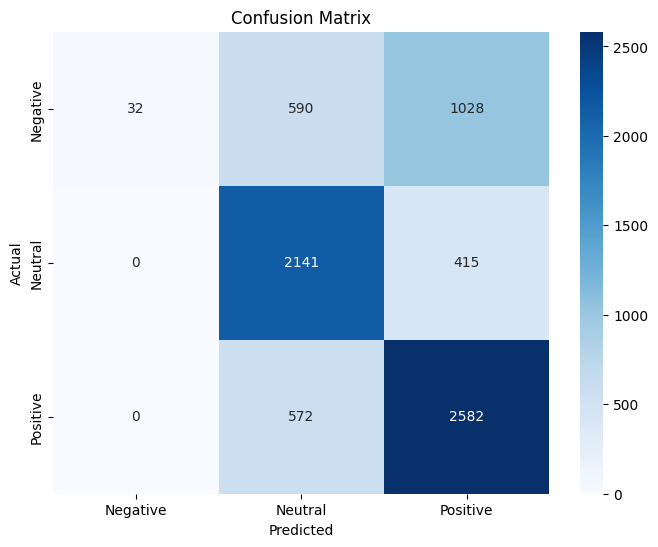

In [23]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()